# Title: Heart Disease Prediction 
`Author:` [Sehar Amjad](https://github.com/seharamjad/Heart-Disease-Prediction-)\
`Date:` 27.Feb.2026\
`Dataset:` [Heart Disease UCI](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data/data)

## Meta-Data (About Dataset)
## Context
This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thalassemia. This database includes 76 attributes, but all published studies relate to the use of a subset of 14 of them. The Cleveland database is the only one used by ML researchers to date. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

### Content
##### Column Descriptions:
* `id` (Unique id for each patient)
* `age` (Age of the patient in years)
* `origin` (place of study)
* `sex` (Male/Female)
* `cp` chest pain type 
   1. typical angina 
   2. atypical angina
   3. non-anginal
   4. asymptomatic
trestbps resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
* `chol` (serum cholesterol in mg/dl)
* `fbs` (if fasting blood sugar > 120 mg/dl)
* `restecg` (resting electrocardiographic results)
-- `Values`: [normal, stt abnormality, lv hypertrophy]
* `thalach`: maximum heart rate achieved
* `exang`: exercise-induced angina (True/ False)
* `oldpeak`: ST depression induced by exercise relative to rest
* `slope`: the slope of the peak exercise ST segment
* `ca`: number of major vessels (0-3) colored by fluoroscopy
* `thal`: [normal; fixed defect; reversible defect]
* `num`: the predicted attribute

### Acknowledgements
#### Creators:
* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
### Relevant Papers:
* Detrano, R., Janosi, A., Steinbrunn, W., Pfisterer, M., Schmid, J., Sandhu, S., Guppy, K., Lee, S., & Froelicher, V. (1989). International application of a new probability * * algorithm for the diagnosis of coronary artery disease. American Journal of Cardiology, 64,304--310.
* David W. Aha & Dennis Kibler. "Instance-based prediction of heart-disease presence with the Cleveland database."
* Gennari, J.H., Langley, P, & Fisher, D. (1989). Models of incremental concept formation. Artificial Intelligence, 40, 11--61.
#### Citation Request:
The authors of the databases have requested that any publications resulting from the use of the data include the names of the principal investigator responsible for the data collection at each institution.
**They would be:**

* Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
* University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
* University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
* V.A. Medical Center, Long Beach and Cleveland Clinic Foundation:Robert Detrano, M.D., Ph.D.

## Aims and Objective:

We will fill this after doing some Exploratory Data Analysis (EDA)

### Import Libraries 
Let's start the project by importing all the libraries that we will need in this project.

In [1]:
# import libraries 

# 1. To handle the data 
import pandas as pd 
import numpy as np 

# 2. Visualize the Dataset 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px

# 3. To Preprocess the Data for Scalling 
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer, KNNImputer

# import Iterative imputer 
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Machine Learning 
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# For Classification Task 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
# from xgboost import XGBClassifier

# Metrics 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
# Load the data from csv file placed in our pc 

df = pd.read_csv(r"C:\Users\HP\Desktop\My AI Course practice\Machine Learning\Heart-Disease-Prediction\heart_disease_uci.csv")

# Print First 5 rows of the dataframe 
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Exploratory Data Analysis (EDA)

### Explore each Column 

In [3]:
# Exploring the datatype of each column 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [4]:
# Checking the Data Shape 
df.shape

(920, 16)

In [5]:
# id Column
df["id"].min(), df["id"].max()

(1, 920)

In [6]:
# age Column 
df["age"].min(), df["age"].max()

(28, 77)

In [7]:
# Let's summarize the age column 
df['age'].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

#### Outputs: 
1. The minimum age to have a heart disease starts from 28 years old and the maximum age to have a heart disease is 77 years old, according to this dataset 

<Axes: xlabel='age', ylabel='Count'>

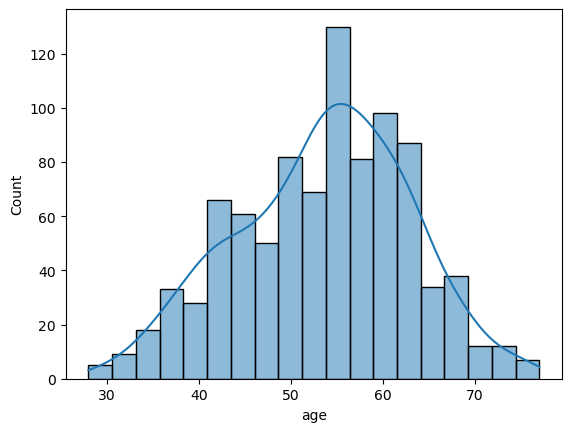

In [8]:
# Draw a Histogram to see the distribution of the age column
sns.histplot(df["age"], kde=True)

Mean: 53.51086956521739
Median: 54.0
Mode: 54


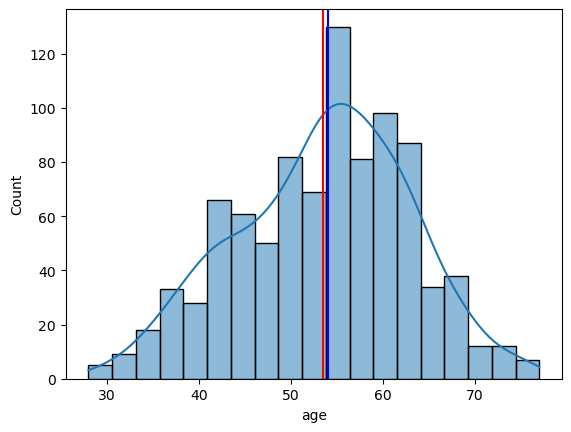

In [9]:
# Plot the mean, median and mode of the age column using sns 
sns.histplot(df["age"], kde=True)
plt.axvline(df["age"].mean(), color="red")
plt.axvline(df["age"].median(), color="green")
plt.axvline(df["age"].mode()[0], color="blue")

# Print the value of the mean, median and mode of age column 
print('Mean:', df['age'].mean())
print('Median:', df['age'].median())
print('Mode:', df['age'].mode()[0])

Let's explore the gender based distribution of the dataset for age column.

In [10]:
# plot the histogram of age column using plotly and coloring this by sex

fig = px.histogram(data_frame=df, x="age", color="sex")
fig.show()


In [11]:
# find the values of sex Columns 
df['sex'].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

In [12]:
# Calculate the percentage of male and female values counts in the data
male_count = 726 
female_count = 194
total_count = male_count + female_count

# Calculate Percentages 
male_percentage = (male_count / total_count) * 100
female_percentage = (female_count / total_count) * 100

# Display the Results 
print(f"Male percentage in the data: {male_percentage:.2f}%")
print(f"Female percentage in the data: {female_percentage:.2f}%")

# Difference 
difference_percentage = ((male_count - female_count) / female_count) * 100
print(f"Males are {difference_percentage:.2f}% more than females in the data.")


Male percentage in the data: 78.91%
Female percentage in the data: 21.09%
Males are 274.23% more than females in the data.


In [13]:
# find the values count of age column grouping by sex column
df.groupby("sex")['age'].value_counts()

sex     age
Female  54     15
        51     11
        62     10
        43      9
        48      9
               ..
Male    77      2
        28      1
        31      1
        33      1
        76      1
Name: count, Length: 91, dtype: int64

In [14]:
# Let's deal with dataset column
# find the unique values in dataset column 
df['dataset'].unique()

array(['Cleveland', 'Hungary', 'Switzerland', 'VA Long Beach'],
      dtype=object)

In [15]:
# find unique values count in dataset column
df['dataset'].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

In [17]:
# plot the countplot of the dataset column
# sns.countplot(data=df, x='dataset', hue='sex')

# Better plots with plotly 
fig = px.bar(df, x='dataset', color='sex')
fig.show()

# Print the values count of dataset column grouping by sex
print(df.groupby("sex")['dataset'].value_counts())

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64


In [23]:
# Make a plot of age column using plotly and coloring this by dataset column
fig = px.histogram(data_frame=df, x="age", color="dataset")
fig.show()

# print the mean, median and mode of age column grouping by dataset column
print(f"Mean of the Data Set: {df.groupby('dataset')['age'].mean()}")
# print('-----------------------------------')
print(f"Median of the Data Set: {df.groupby('dataset')['age'].median()}")
# print('-----------------------------------')
print(f"Mode of the Data Set: {df.groupby('dataset')['age'].mode()}")

Mean of the Data Set: dataset
Cleveland        54.351974
Hungary          47.894198
Switzerland      55.317073
VA Long Beach    59.350000
Name: age, dtype: float64
Median of the Data Set: dataset
Cleveland        55.5
Hungary          49.0
Switzerland      56.0
VA Long Beach    60.0
Name: age, dtype: float64


AttributeError: 'SeriesGroupBy' object has no attribute 'mode'

#### Let's Explore the cp (Chest Pain) column:

In [61]:
# Value counts of the cp column 
df['cp'].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

<Axes: xlabel='cp', ylabel='count'>

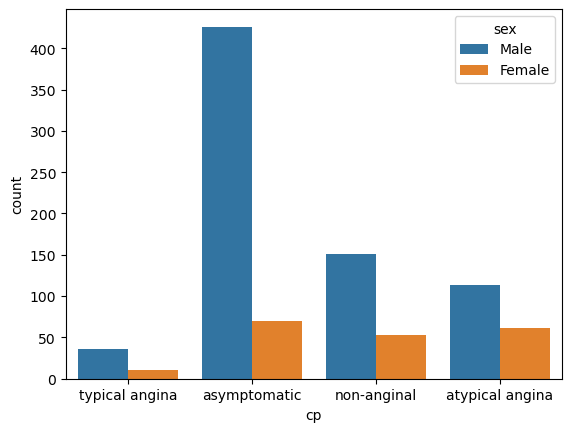

In [63]:
# count plot of cp column by sex column 
sns.countplot(df, x='cp', hue='sex')

<Axes: xlabel='cp', ylabel='count'>

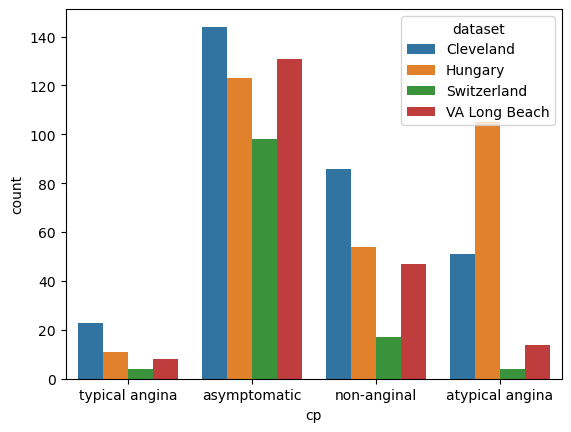

In [64]:
# count plot of cp column by dataset column 
sns.countplot(df, x='cp', hue='dataset')

<Axes: xlabel='cp', ylabel='count'>

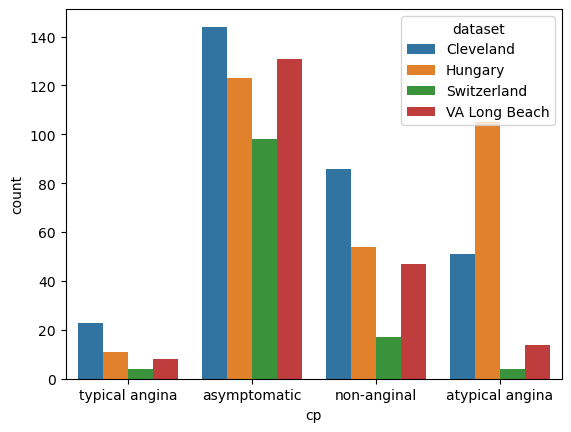

In [66]:
# count plot of cp column by age column 
sns.countplot(df, x='cp', hue='dataset')

In [62]:
# draw the plot of the age column groupby by cp column using plotly
fig = px.histogram(data_frame=df, x='age', color='cp')
fig.show()

#### Let's explore the trestbps (resting blood pressure) column:

The normal resting blood pressure is 120/80 mm Hg

`Write here, what will happen if the blood pressure is high or low and then you can bin the data based on those values.`

In [68]:
# find the value counts of trestbps column
df['trestbps'].describe()

count    861.000000
mean     132.132404
std       19.066070
min        0.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: trestbps, dtype: float64

<Axes: xlabel='trestbps', ylabel='Count'>

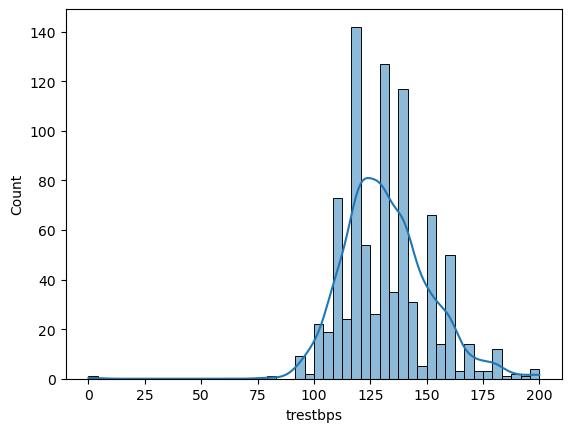

In [88]:
# Create a histplot of trestbps column
sns.histplot(df['trestbps'], kde=True) 

In [ ]:
# Deal with missing values in the trestbps column
# Find the percentage of missing values in the trestbps column
# print(f"Percentage of missing values in trestbps column: {df['trestbps'].isnull().mean() * 100:.2f}%")
# Try to delete the 'overwritten' attributes

In [ ]:
# Impute the missing values in the trestbps column using iterative imputer
# Create an object of iterative imputer
imputer_1 = IterativeImputer(max_iter=10, random_state=42)

# Fit the imputer on the trestbps column
imputer_1.fit(df[['trestbps']])

# transform the trestbps column 
df['trestbps'] = imputer_1.transform(df[['trestbps']])

# Check the missing values in trestbps column 
# print(f"Missing values in trestbps column: {df['trestbps'].isnull().sum()}")

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  920 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
# impute missing values using iterative imputer for ca, oldpeak, thalch, chol columns 
imputer_2 = IterativeImputer(max_iter=10, random_state=42)

# Imputer is apply on float values, it does not apply on object 
# ca, oldpeak, thalch, chol
# -> these all are float values and have the missing values 

# fit_transform the imputer on ca, oldpeak, thalch, chol columns 
df['ca'] = imputer_2.fit_transform(df[['ca']])
df['oldpeak'] = imputer_2.fit_transform(df[['oldpeak']])
df['thalch'] = imputer_2.fit_transform(df[['thalch']])   
df['chol'] = imputer_2.fit_transform(df[['chol']])



### Let's impute the missing values in thal columns by using ML models

In [ ]:
df['thal'].isnull().sum()
# 486 missing values
# print(f"The missing values in thal column are: {df['thal'].isnull().sum()}")

np.int64(486)

In [111]:
df['thal'].value_counts()

thal
normal               196
reversable defect    192
fixed defect          46
Name: count, dtype: int64

In [124]:
classifier_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num']
bool_cols = ['fbs', 'exang']
regressor_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [ ]:
# def impute_categorical_missing_data(passed_col):
    
#     df_null = df[df[passed_col].isnull()]
#     df_not_null = df[df[passed_col].notnull()]

#     X = df_not_null.drop(passed_col, axis=1)
#     y = df_not_null[passed_col]
    
#     # other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
#     label_encoder = LabelEncoder()

#     for col in X.columns:
#         if X[col].dtype == 'object' or X[col].dtype == 'category':
#             X[col] = label_encoder.fit_transform(X[col])

#     if passed_col in bool_cols:
#         y = label_encoder.fit_transform(y)
        
#     # iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

#     # for col in other_missing_cols:
#         if X[col].isnull().sum() > 0:
#             col_with_missing_values = X[col].values.reshape(-1, 1)
#             # imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
#             X[col] = imputed_values[:, 0]
#         else:
#             pass
    
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     rf_classifier = RandomForestClassifier()

#     rf_classifier.fit(X_train, y_train)

#     y_pred = rf_classifier.predict(X_test)

#     acc_score = accuracy_score(y_test, y_pred)

#     print("The feature '"+ passed_col+ "' has been imputed with", round((acc_score * 100), 2), "accuracy\n")

#     X = df_null.drop(passed_col, axis=1)

#     for col in X.columns:
#         if X[col].dtype == 'object' or X[col].dtype == 'category':
#             X[col] = label_encoder.fit_transform(X[col])

#     # for col in other_missing_cols:
#         if X[col].isnull().sum() > 0:
#             col_with_missing_values = X[col].values.reshape(-1, 1)
#             # imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
#             X[col] = imputed_values[:, 0]
#         else:
#             pass
                
#     if len(df_null) > 0: 
#         df_null[passed_col] = rf_classifier.predict(X)
#         if passed_col in bool_cols:
#             df_null[passed_col] = df_null[passed_col].map({0: False, 1: True})
#         else:
#             pass
#     else:
#         pass

#     df_combined = pd.concat([df_not_null, df_null])
    
#     return df_combined[passed_col]

# def impute_continuous_missing_data(passed_col):
    
#     df_null = df[df[passed_col].isnull()]
#     df_not_null = df[df[passed_col].notnull()]

#     X = df_not_null.drop(passed_col, axis=1)
#     y = df_not_null[passed_col]
    
#     # other_missing_cols = [col for col in missing_data_cols if col != passed_col]
    
#     label_encoder = LabelEncoder()

#     for col in X.columns:
#         if X[col].dtype == 'object' or X[col].dtype == 'category':
#             X[col] = label_encoder.fit_transform(X[col])
    
#     # iterative_imputer = IterativeImputer(estimator=RandomForestRegressor(random_state=42), add_indicator=True)

#     # for col in other_missing_cols:
#         if X[col].isnull().sum() > 0:
#             col_with_missing_values = X[col].values.reshape(-1, 1)
#             imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
#             X[col] = imputed_values[:, 0]
#         else:
#             pass
    
#     X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#     # rf_regressor = RandomForestRegressor()

#     rf_regressor.fit(X_train, y_train)

#     y_pred = rf_regressor.predict(X_test)

#     # print("MAE =", mean_absolute_error(y_test, y_pred), "\n")
#     # print("RMSE =", mean_squared_error(y_test, y_pred, squared=False), "\n")
#     # print("R2 =", r2_score(y_test, y_pred), "\n")

#     X = df_null.drop(passed_col, axis=1)

#     for col in X.columns:
#         if X[col].dtype == 'object' or X[col].dtype == 'category':
#             X[col] = label_encoder.fit_transform(X[col])

#     for col in other_missing_cols:
#         if X[col].isnull().sum() > 0:
#             col_with_missing_values = X[col].values.reshape(-1, 1)
#             imputed_values = iterative_imputer.fit_transform(col_with_missing_values)
#             X[col] = imputed_values[:, 0]
#         else:
#             pass
                
#     if len(df_null) > 0: 
#         df_null[passed_col] = rf_regressor.predict(X)
#     else:
#         pass

#     df_combined = pd.concat([df_not_null, df_null])
    
#     return df_combined[passed_col]
# # for col in missing_data_cols:
#     print("Missing Values", col, ":", str(round((df[col].isnull().sum() / len(df)) * 100, 2))+"%")
#     if col in classifier_cols:
#         df[col] = impute_categorical_missing_data(col)
#     elif col in regressor_cols:
#         df[col] = impute_continuous_missing_data(col)
#     else:
#         pass

In [ ]:
# use the function to impute the missing values in thal column 
# df = rf_categorical_imputer(df, "thal")

# Check the missing values in thal column 
# print(f"Missing values in thal column: {df['thal'].isnull().sum()}")

In [108]:
# let's impute other column with missing values
(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

# print(f"Missing values in chol column: {df.isnull().sum()}")

thal        52.826087
slope       33.586957
fbs          9.782609
exang        5.978261
restecg      0.217391
id           0.000000
sex          0.000000
age          0.000000
chol         0.000000
trestbps     0.000000
cp           0.000000
dataset      0.000000
oldpeak      0.000000
thalch       0.000000
ca           0.000000
num          0.000000
dtype: float64

#### Outputs:

1. The minimum age to have a heart disease starts from 28 years old.
2. Most of the people get heart disease at the age of 53-54 years.
3. Most of the Males and Females get are with heart diseaseat the age of 54-55 years.
4. Male percentage in the data: 78.91%
5. Female percentage in the data: 21.09%
6. Males are 274.23% more than females in the data.
7. We have heighest number of people from Cleveland (304) and lowest from Switzerland (123)
   1. The heighest number of females in this dataset are from Cleveland (97) and the lowest from VA Long Beach (06)
   2. The heighest number of males in this dataset are from Hungary (212) and the lowest from Switzerland (113)
8. `Write down the observation here about mean, median and mode of age column, groupedby dataset column.`
9. `Write down the observation from cp column here.`